In [1]:
import matplotlib.pyplot as plt
import numpy as np
import glob

from simla_variables import SimlaVar
from simla_utils import bcd_spectrum, interp_superdark, load_superdark_sets
from simladb import query, simladb, DB_bcd, DB_foreground

/Users/grant/anaconda3/envs/simlaenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
simlapath = SimlaVar().simlapath
plotpath = simlapath+'validations/plots/superdarks/'
sd_dir = simlapath+'superdarks/'

In [3]:
# Load in the superdarks
superdark_sets = load_superdark_sets(sd_dir)
keys = superdark_sets.keys()

In [4]:
extractor = bcd_spectrum()

# Zodi Bin Stats

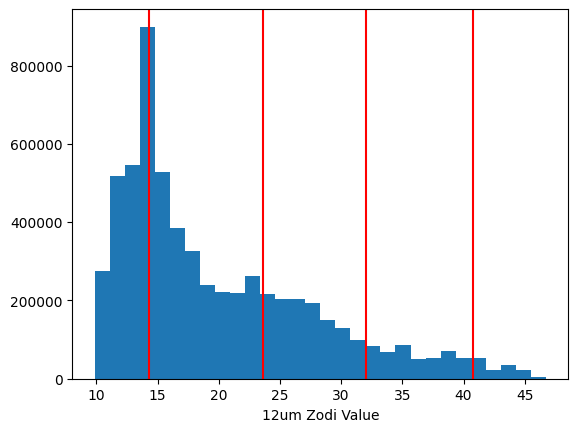

In [5]:
all_zodi = query(simladb.select(DB_foreground.ZODI_12)\
                 .where(((DB_bcd.CHNLNUM==0)|(DB_bcd.CHNLNUM==2))))['ZODI_12'].to_numpy()
bin_centers = np.load(simlapath+'storage/fiducial_zodis.npy')

plt.hist(all_zodi, bins=30)
for b in bin_centers:
    plt.axvline(b, color='red')
plt.xlabel('12um Zodi Value')
plt.savefig(plotpath+'zodi_hist_with_binvals.pdf', format='pdf')
plt.show()

# Superdarks Binned by Zodi

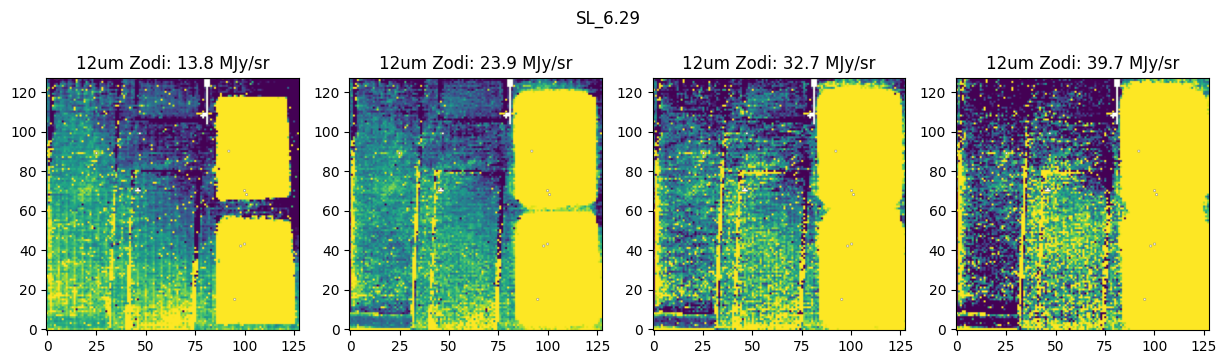

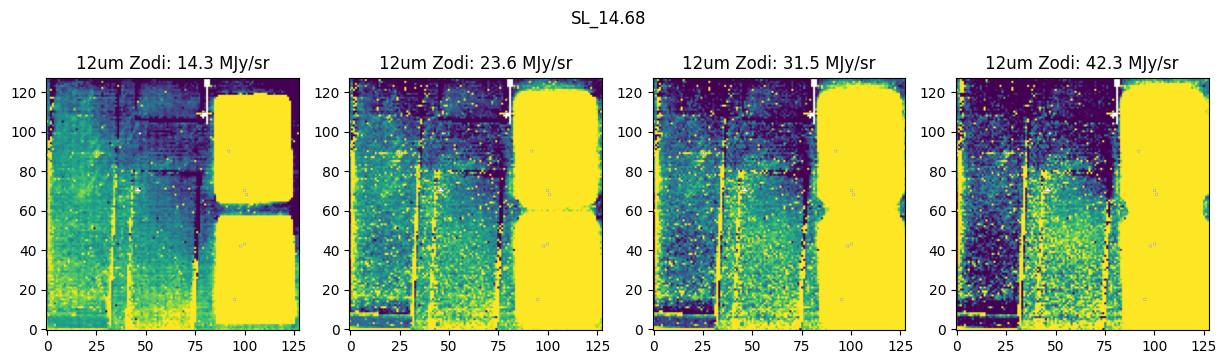

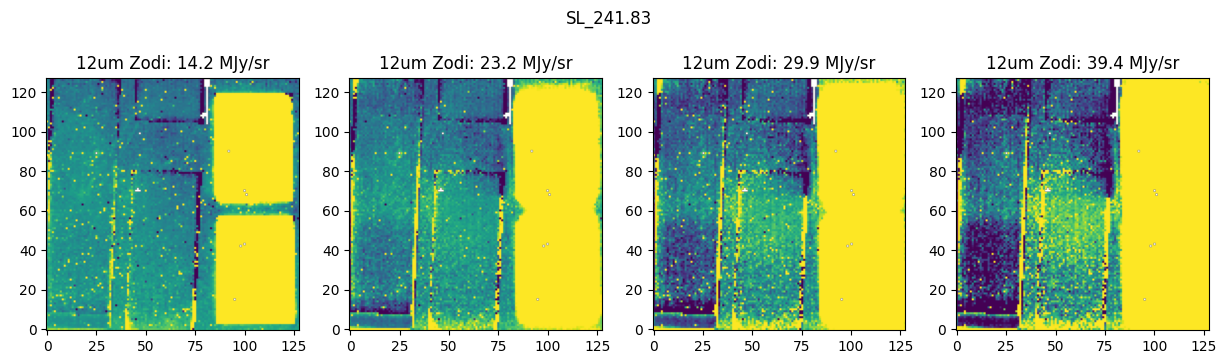

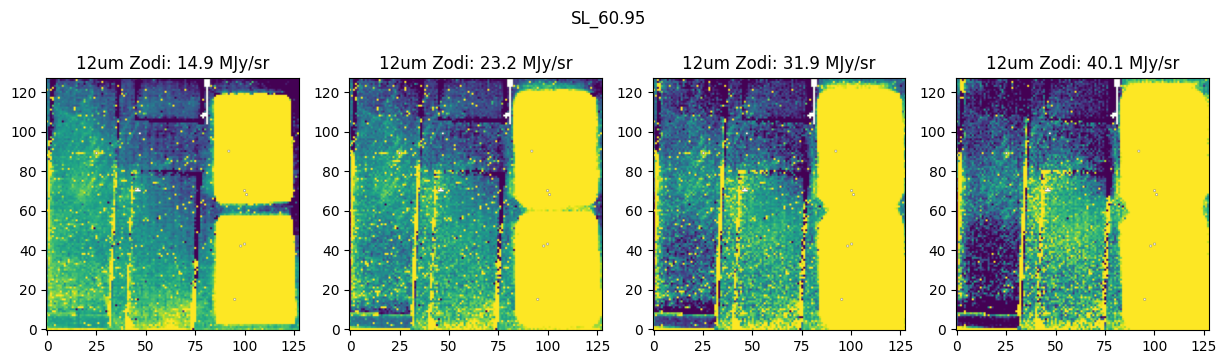

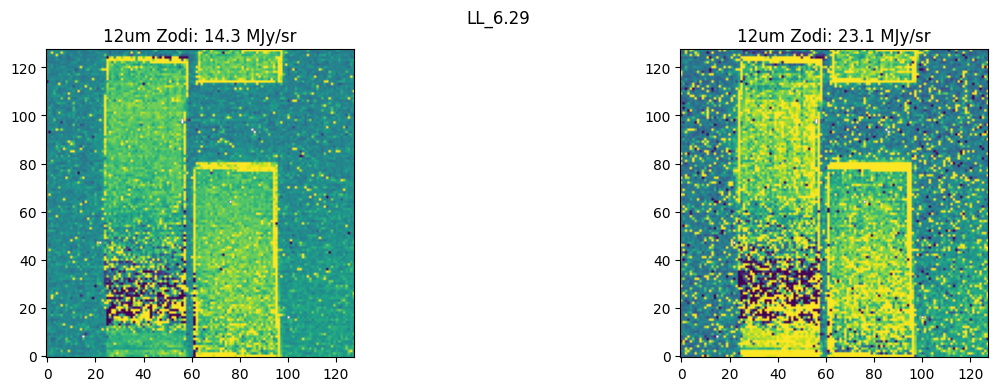

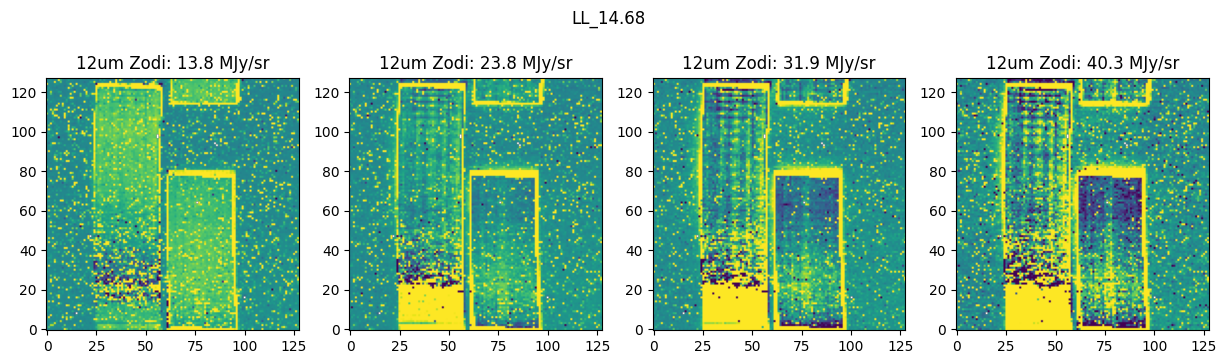

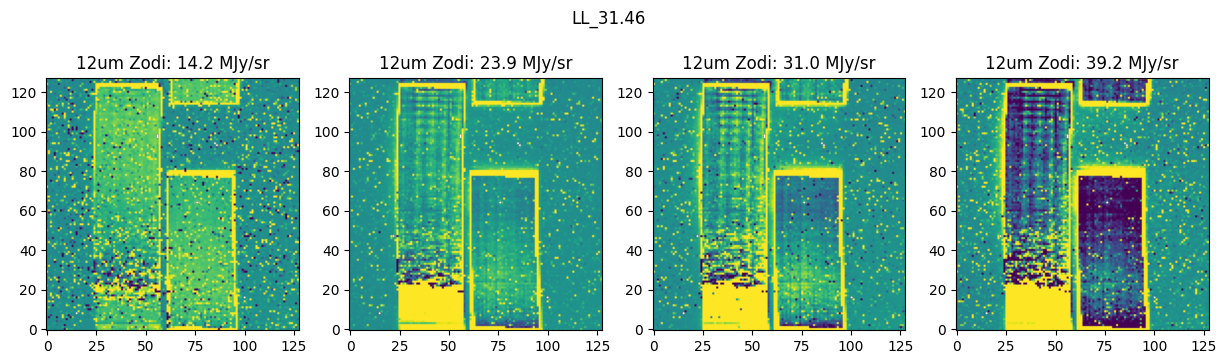

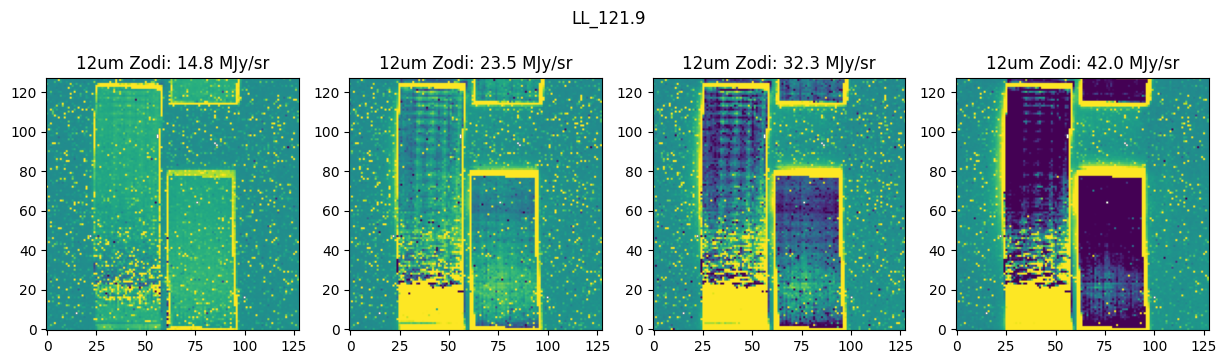

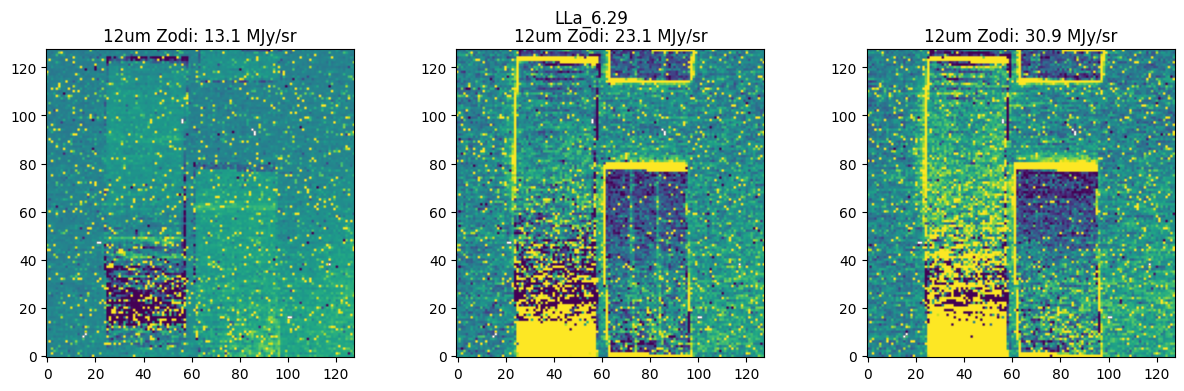

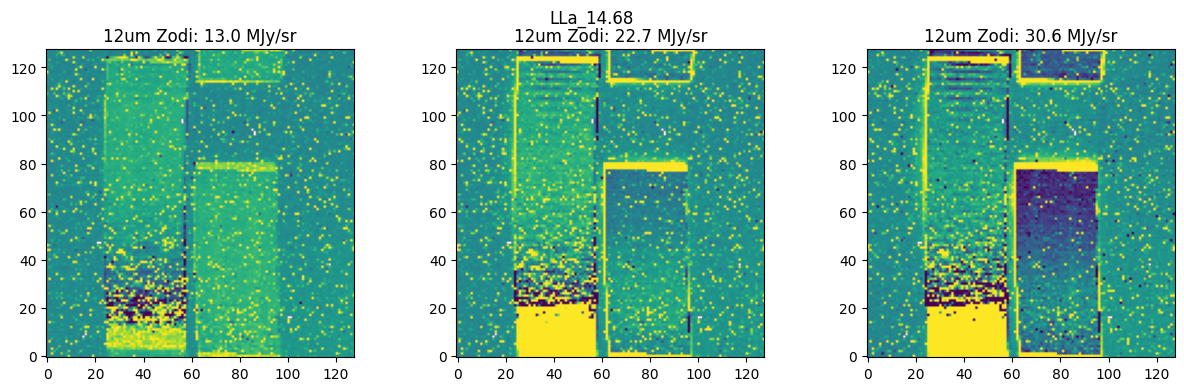

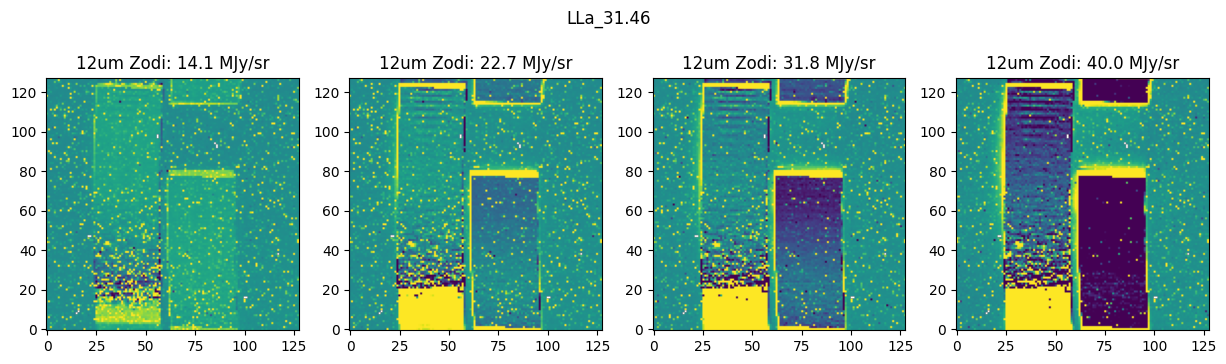

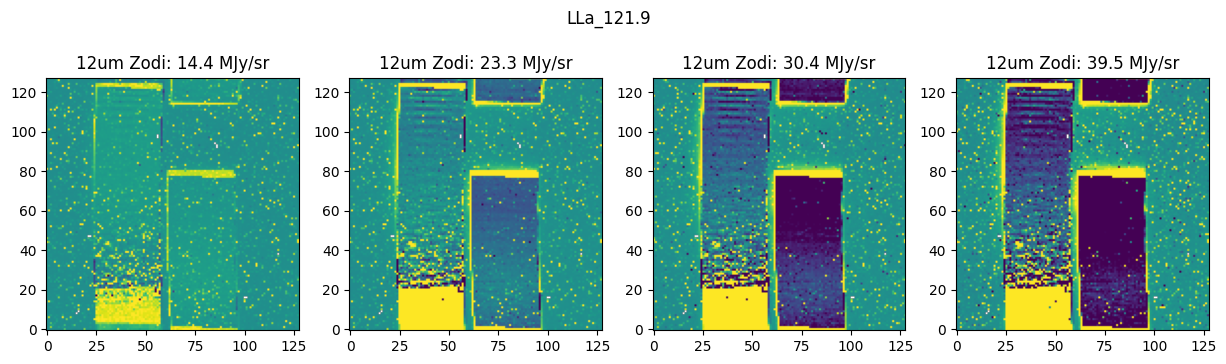

In [6]:
for key in keys:
    superdarks = superdark_sets[key]['set']
    zodis = superdark_sets[key]['fiducial_zodis']
    fig, axs = plt.subplots(1, len(superdarks), figsize=(15, 4))
    plt.suptitle(key)
    for i in range(len(superdarks)):
        plt.subplot(1, len(superdarks), i+1)
        plt.title('12um Zodi: '+str(zodis[i])+' MJy/sr')
        if 'SL' in key: plt.imshow(superdarks[i], origin='lower', vmin=-10, vmax=10)
        if 'LL' in key: plt.imshow(superdarks[i], origin='lower', vmin=-25, vmax=25)
    plt.savefig(plotpath+key+'.pdf', format='pdf')
    plt.show()

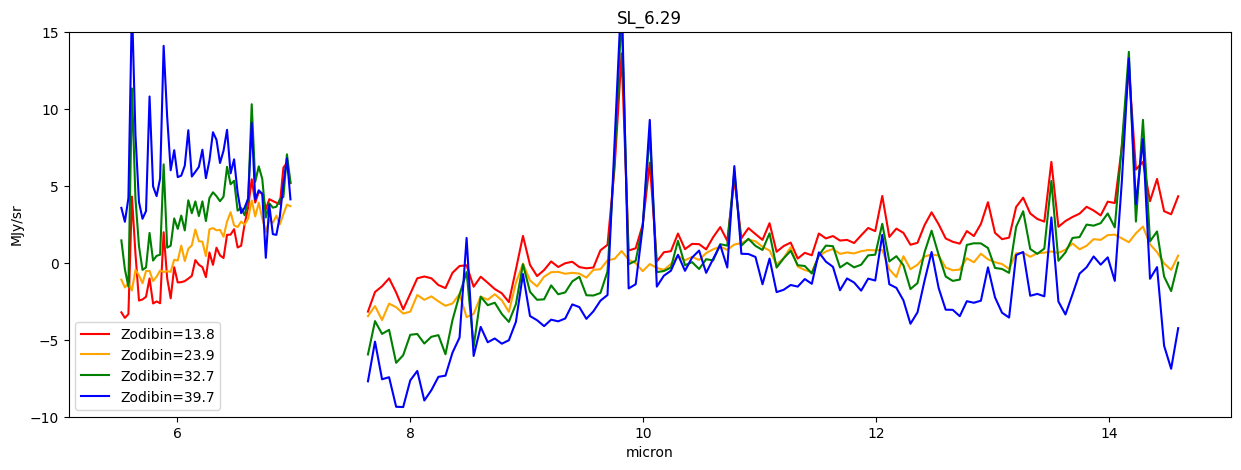

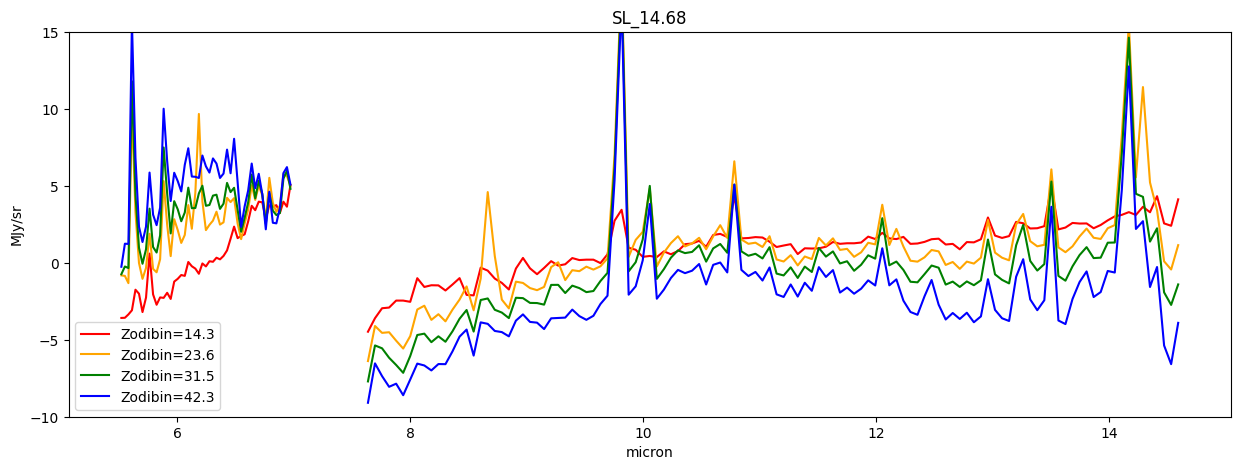

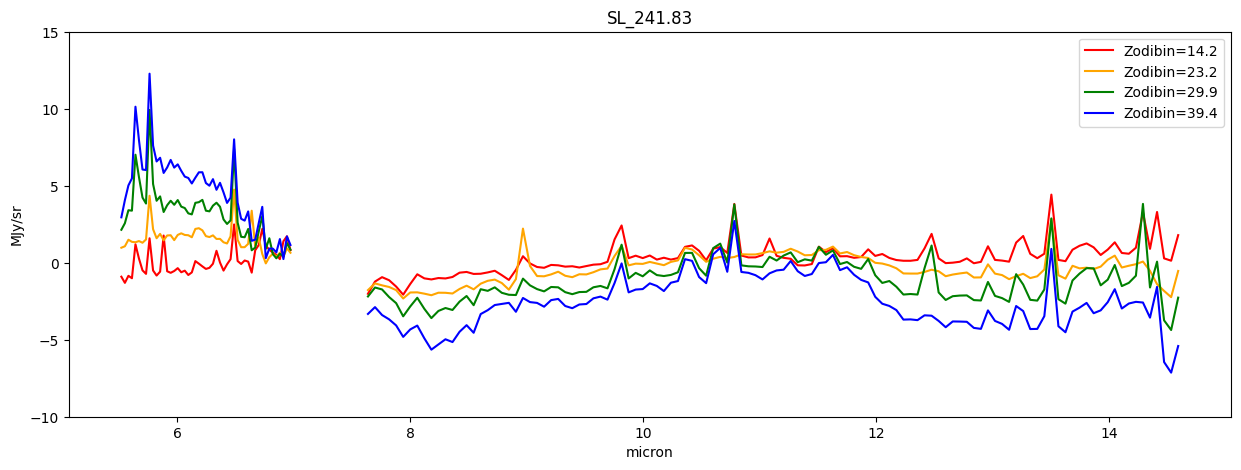

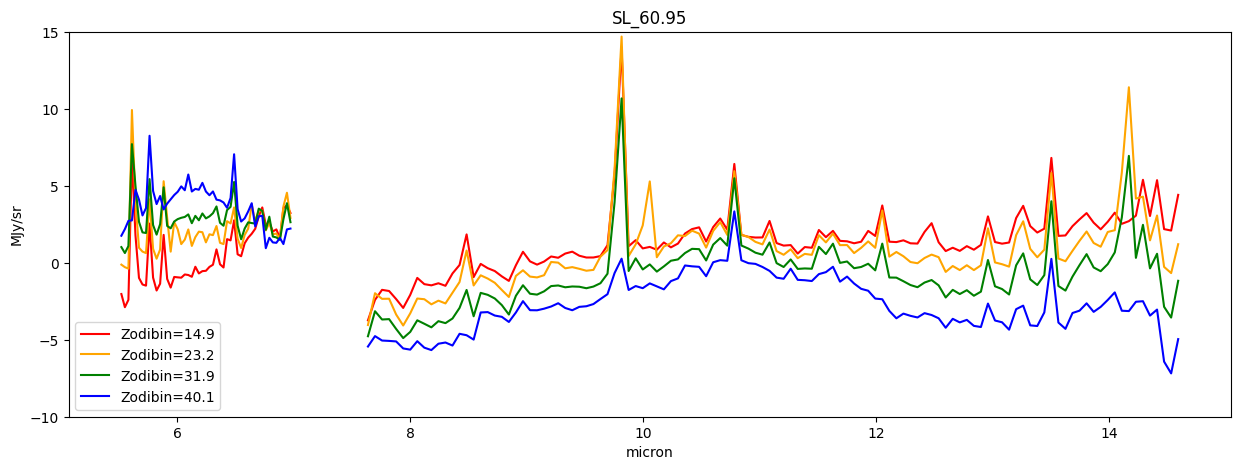

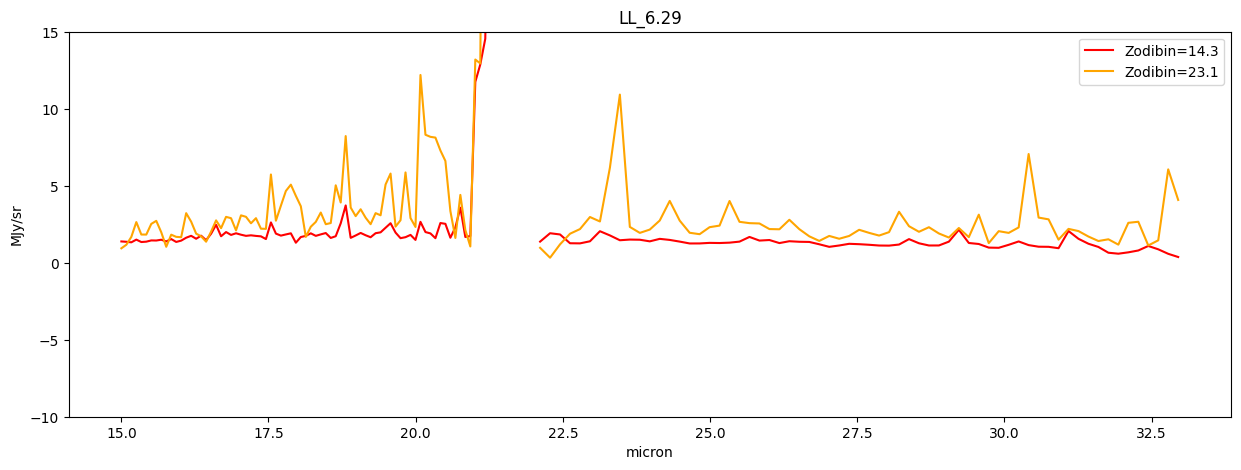

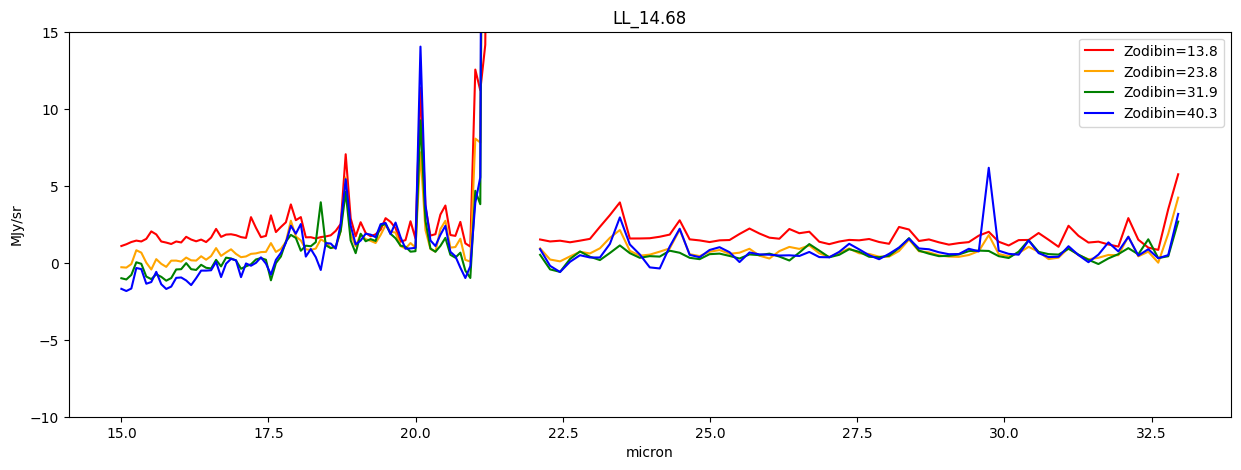

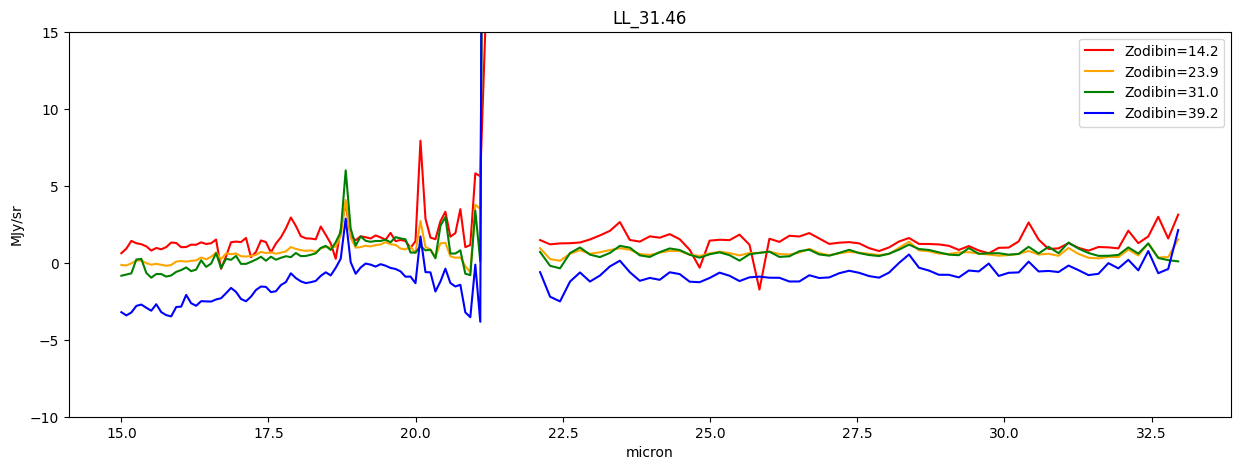

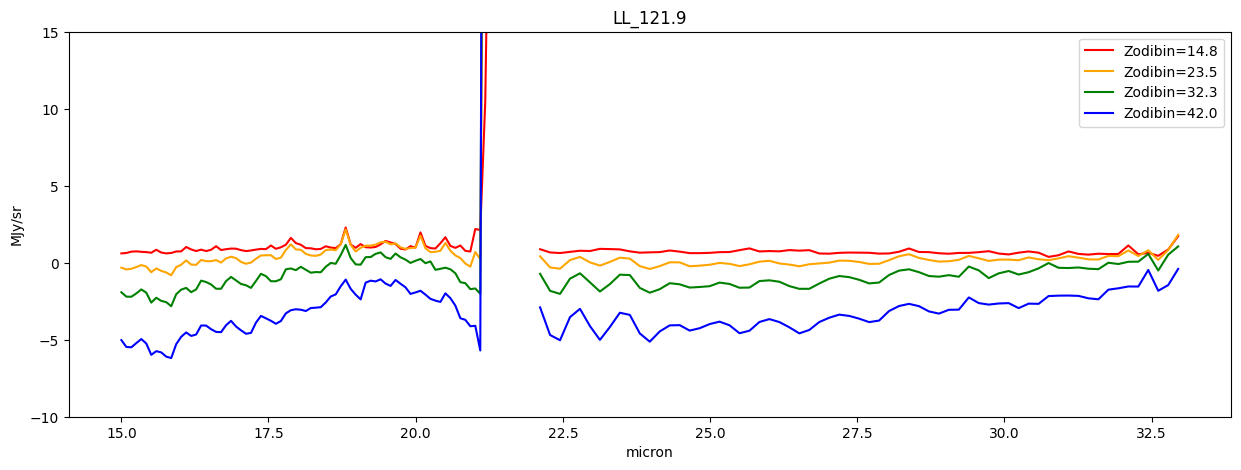

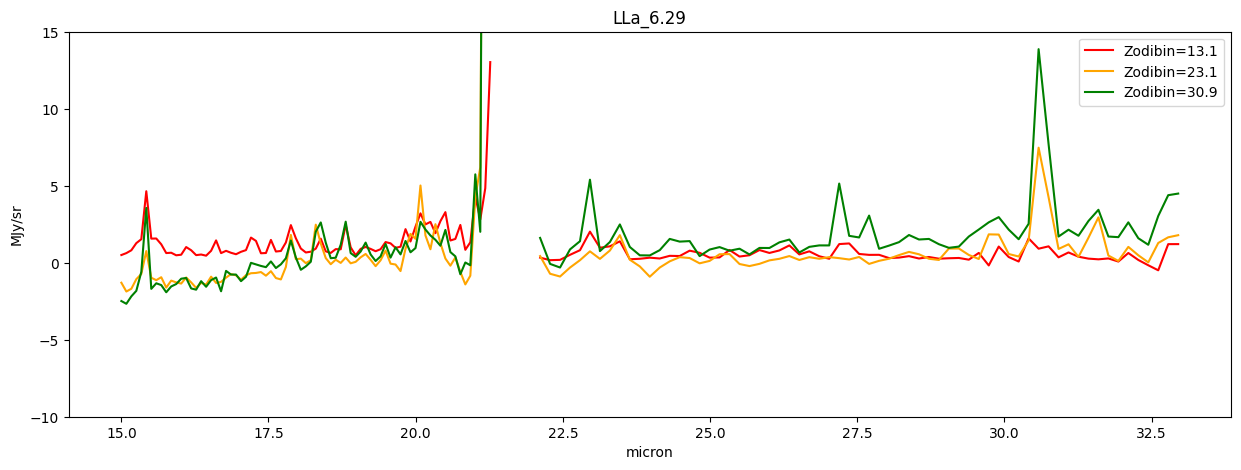

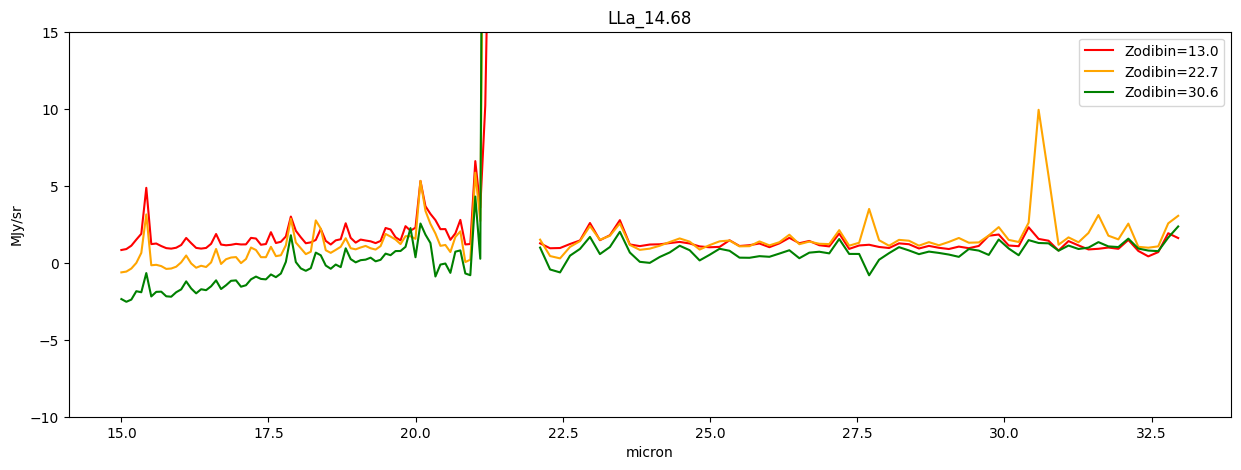

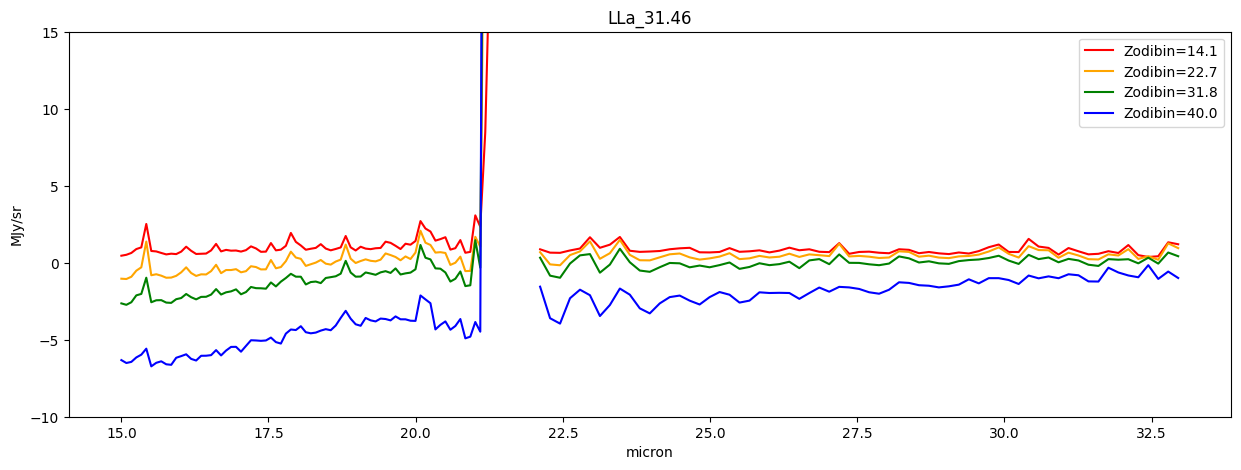

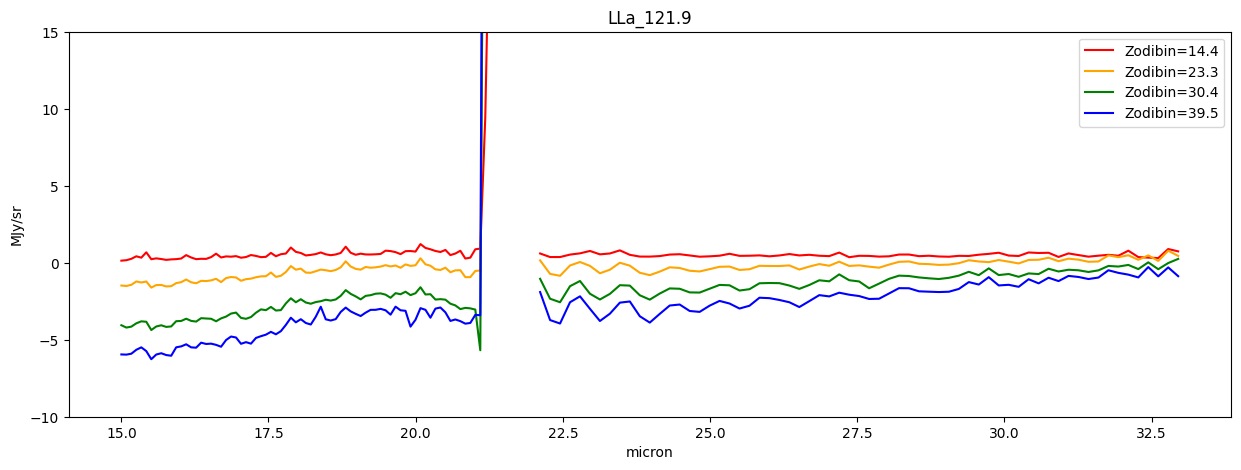

In [7]:
colors = ['red', 'orange', 'green', 'blue', 'purple']

for key in keys:
    
    superdarks = superdark_sets[key]['set']
    zodis = superdark_sets[key]['fiducial_zodis']

    ordername = key.split('_')[0]
    if ordername == 'SL': 
        chnlnum = 0
        header = {'CHNLNUM':0, 'MJD_OBS':0}
    elif ordername == 'LL':
        chnlnum = 2
        header = {'CHNLNUM':2, 'MJD_OBS':0}
    elif ordername == 'LLa':
        chnlnum = 2
        header = {'CHNLNUM':2, 'MJD_OBS':60000}

    plt.rcParams["figure.figsize"] = (15, 5)
    plt.title(key)
    for i in range(len(superdarks)):
        
        dat = superdarks[i]
        l1, f1 = extractor.fullslit_bcd_spectrum(dat, header, 1)
        l2, f2 = extractor.fullslit_bcd_spectrum(dat, header, 2)

        plt.plot(l1, f1, label='Zodibin='+str(round(zodis[i],2)), color=colors[i])
        plt.plot(l2, f2, color=colors[i])
        
    plt.xlabel('micron')
    plt.ylabel('MJy/sr')
    plt.ylim(-10, 15)
    plt.legend()
    plt.savefig(plotpath+'spectra_'+key+'.pdf', format='pdf')
    plt.show()

# Depth of the Superdarks

In [8]:
for key in keys:
    depths = superdark_sets[key]['depth']
    zodis = superdark_sets[key]['fiducial_zodis']
    print(key+':', np.nanmedian(depths, axis=(1,2)))

SL_6.29: [1203.  260.   38.    8.]
SL_14.68: [3204. 3776. 2501.  648.]
SL_241.83: [4252.  982.  613.  238.]
SL_60.95: [22236.  8396.  2634.   596.]
LL_6.29: [22. 12.]
LL_14.68: [684.  77.  17.   4.]
LL_31.46: [6635.  636.  363.  129.]
LL_121.9: [26736.  4025.  1070.   202.]
LLa_6.29: [118.   4.   4.]
LLa_14.68: [299. 503.  34.]
LLa_31.46: [3851.  918. 1015.  120.]
LLa_121.9: [15432.  5167.  2187.   283.]


# Spectra of Interpolated Superdarks
AKA the "tailored superdarks." Here's a few random examples with the spectra of the superdarks they are interpolated between.
NOTE: If the zodi value of a BCD is outside of the range of zodi bin centers, it will appear as nearly identical to one of the bounding superdarks.

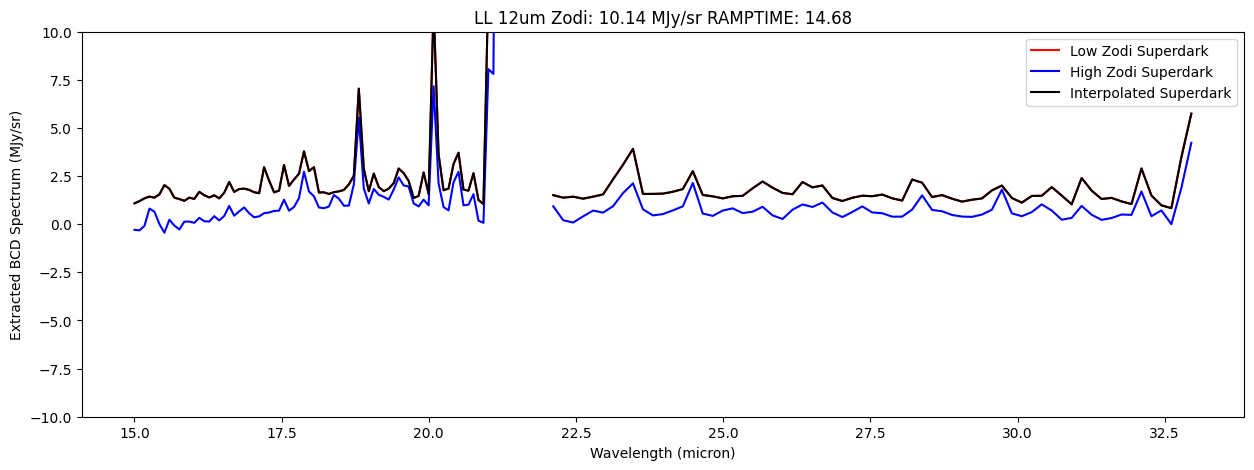

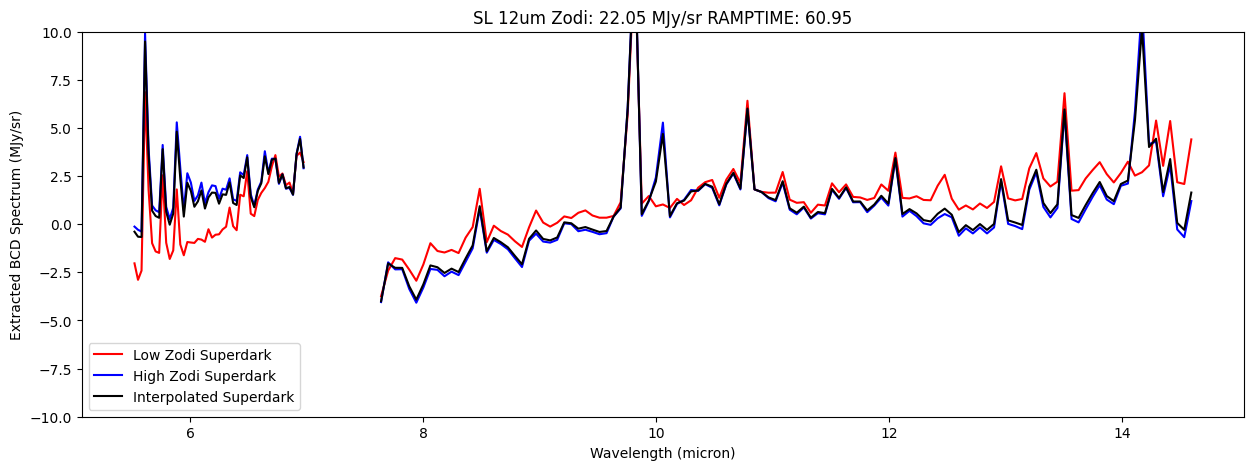

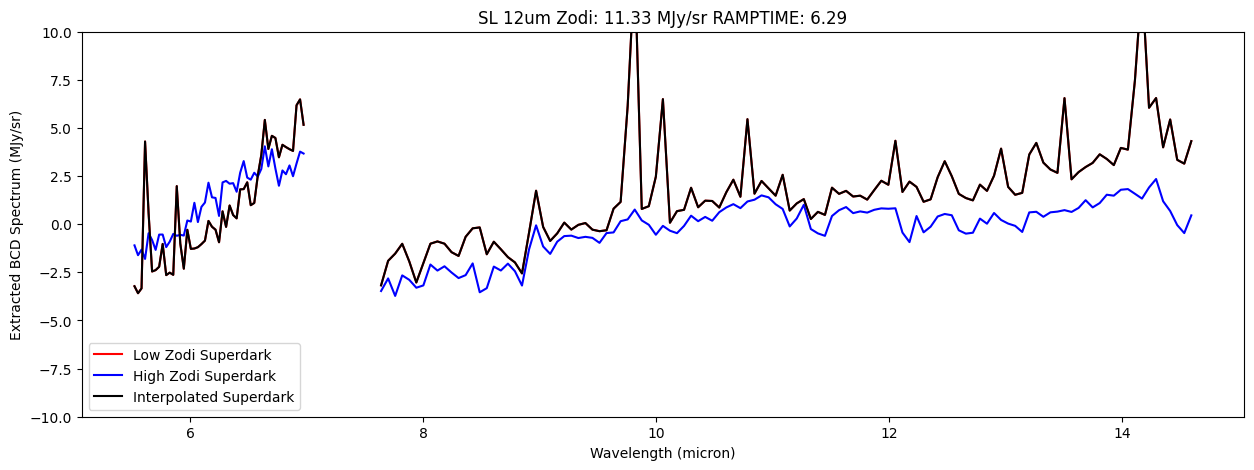

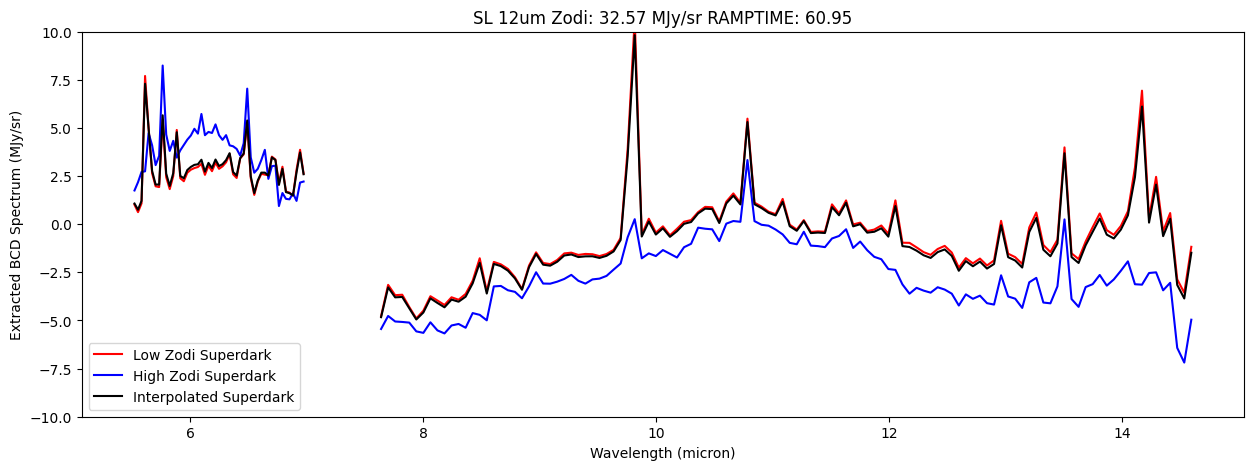

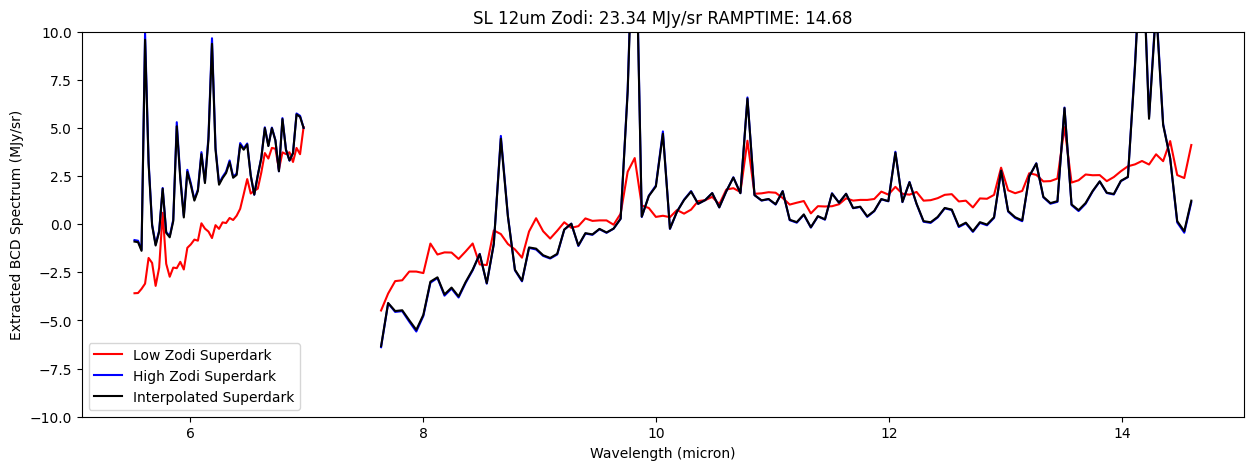

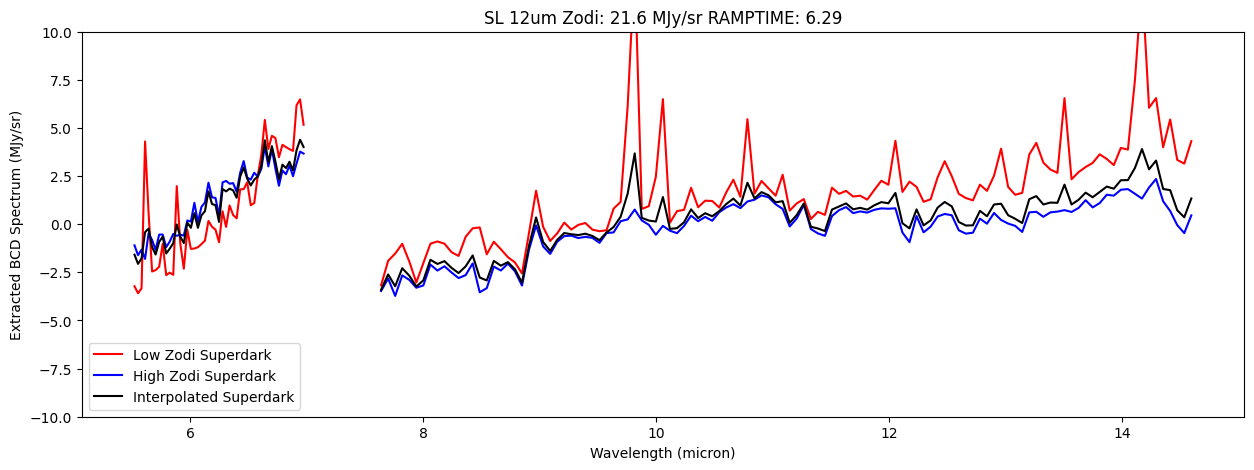

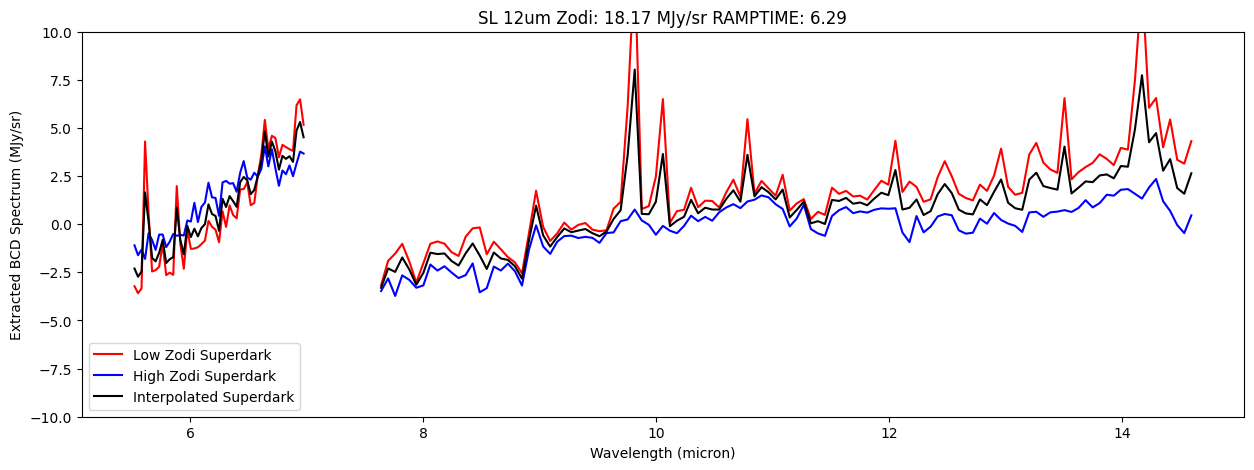

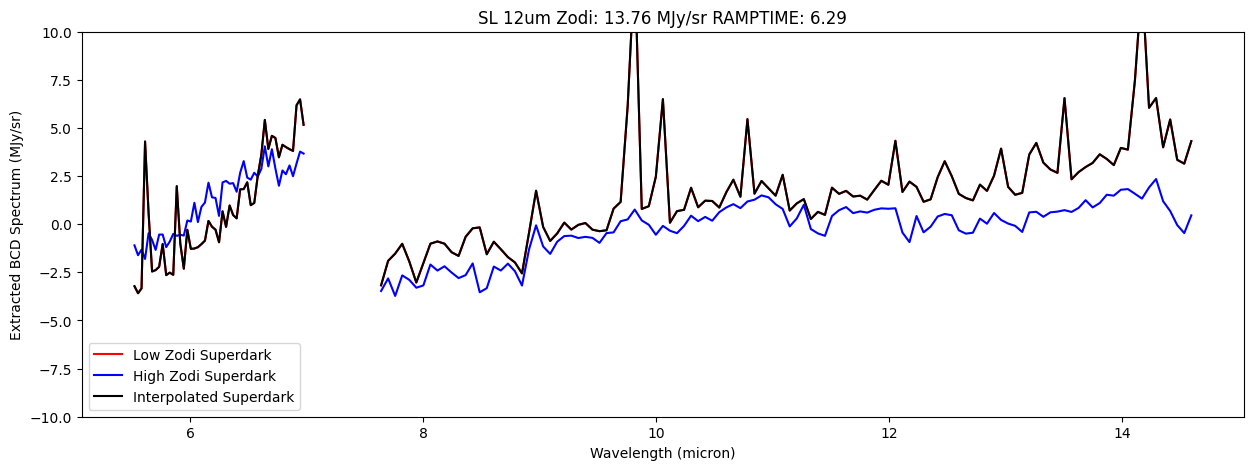

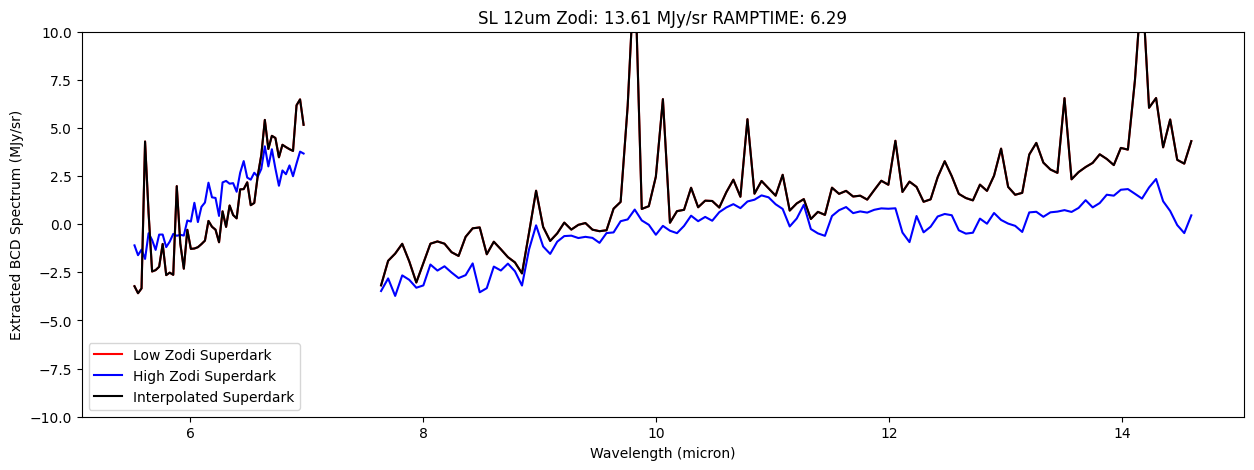

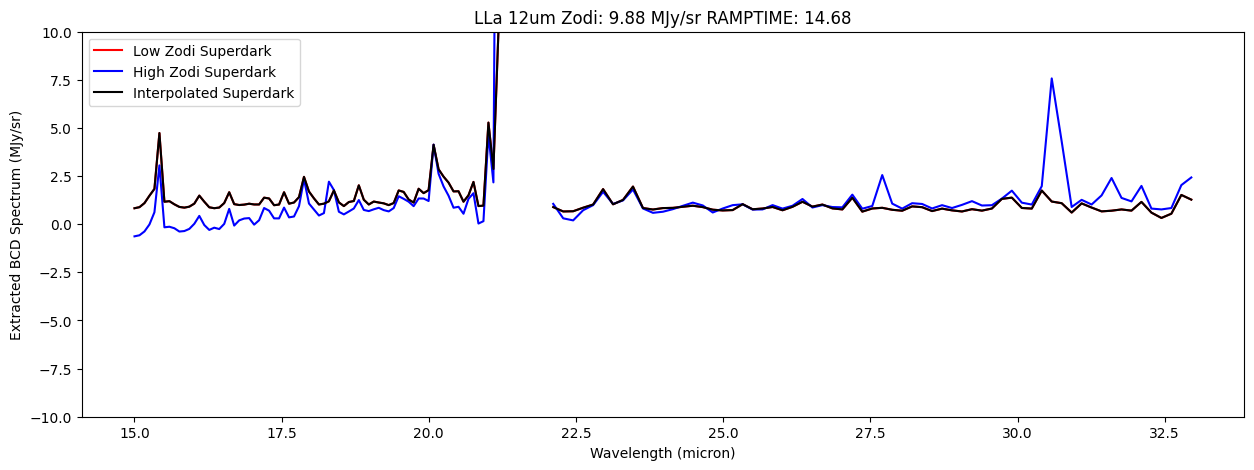

In [9]:
sample = glob.glob(sd_dir+'tailored_superdarks/*')
sample = np.random.choice(np.asarray([i for i in sample if 'unc' not in i]), 10)

for tsd in sample:
    
    split = tsd.split('/')[-1].split('_')
    aor, ordername = int(split[0]), split[1].split('.')[0]
    
    if ordername == 'SL': 
        chnlnum = 0
        header = {'CHNLNUM':0, 'MJD_OBS':0}
    elif ordername == 'LL':
        chnlnum = 2
        header = {'CHNLNUM':2, 'MJD_OBS':0}
    elif ordername == 'LLa':
        chnlnum = 2
        header = {'CHNLNUM':2, 'MJD_OBS':60000}
        
    q = query(simladb.select(DB_bcd.RAMPTIME, DB_bcd.MJD_OBS, DB_foreground.ZODI_12)\
              .where((DB_bcd.AORKEY==aor)&(DB_bcd.CHNLNUM==chnlnum)))
    ramp, mjd, zodi = q['RAMPTIME'][0], q['MJD_OBS'][0], q['ZODI_12'][0]

    if chnlnum == 2 and mjd >= SimlaVar().ll_gain_change_mjd:
        ordername = 'LLa'
    
    sd_set = superdark_sets[ordername+'_'+str(ramp)]

    interp_dat = np.load(tsd)
    _, _unc, low_sd, high_sd = interp_superdark(zodi, sd_set, return_set=True)

    l1, f1_interp = extractor.fullslit_bcd_spectrum(interp_dat, header, 1)
    l2, f2_interp = extractor.fullslit_bcd_spectrum(interp_dat, header, 2)

    l1, f1_low_sd = extractor.fullslit_bcd_spectrum(low_sd, header, 1)
    l2, f2_low_sd = extractor.fullslit_bcd_spectrum(low_sd, header, 2)

    l1, f1_high_sd = extractor.fullslit_bcd_spectrum(high_sd, header, 1)
    l2, f2_high_sd = extractor.fullslit_bcd_spectrum(high_sd, header, 2)

    ###

    # l1, f1_interp2 = extractor.fullslit_bcd_spectrum(_, header, 1)
    # l2, f2_interp2 = extractor.fullslit_bcd_spectrum(_, header, 2)
    # plt.plot(l1, f1_interp2, color='black', ls='dashed', lw=3)
    # plt.plot(l2, f2_interp2, color='black', ls='dashed', lw=3)

    # plt.imshow(low_sd, origin='lower', vmin=-10, vmax=10)
    # plt.show()
    # plt.imshow(_, origin='lower', vmin=-10, vmax=10)
    # plt.show()
    # plt.imshow(high_sd, origin='lower', vmin=-10, vmax=10)
    # plt.show()
    
    ###

    plt.rcParams["figure.figsize"] = (15, 5)
    plt.title(ordername+' 12um Zodi: '+str(round(zodi,2))+' MJy/sr RAMPTIME: '+str(ramp))
    plt.plot(l1, f1_low_sd, color='red', label='Low Zodi Superdark')
    plt.plot(l2, f2_low_sd, color='red')
    plt.plot(l1, f1_high_sd, color='blue', label='High Zodi Superdark')
    plt.plot(l2, f2_high_sd, color='blue')
    plt.plot(l1, f1_interp, color='black', label='Interpolated Superdark')
    plt.plot(l2, f2_interp, color='black')
    plt.ylim(-10, 10)
    plt.legend()
    plt.xlabel('Wavelength (micron)')
    plt.ylabel('Extracted BCD Spectrum (MJy/sr)')
    plt.savefig(plotpath+str(aor)+'_'+ordername+'.pdf', format='pdf')
    plt.show()